In [3]:
import pandas as pd

df = pd.read_csv("../data/hillstrom.csv")

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (64000, 12)

Columns:
['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel', 'segment', 'visit', 'conversion', 'spend']


In [4]:
print("Segment values:")
print(df["segment"].value_counts())

print("\nConversion:")
print(df["conversion"].value_counts())

print("\nVisit:")
print(df["visit"].value_counts())

print("\nData types:")
print(df.dtypes)

Segment values:
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

Conversion:
conversion
0    63422
1      578
Name: count, dtype: int64

Visit:
visit
0    54606
1     9394
Name: count, dtype: int64

Data types:
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
dtype: object


In [5]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values:")
print(df.nunique())

Missing values:
recency            0
history_segment    0
history            0
mens               0
womens             0
zip_code           0
newbie             0
channel            0
segment            0
visit              0
conversion         0
spend              0
dtype: int64

Duplicate rows: 6562

Unique values:
recency               12
history_segment        7
history            34833
mens                   2
womens                 2
zip_code               3
newbie                 2
channel                3
segment                3
visit                  2
conversion             2
spend                429
dtype: int64


In [7]:
print("Total rows:", len(df))
print("Unique rows:", df.drop_duplicates().shape[0])
print("Duplicate rows:", df.duplicated().sum())

print("\nDuplicate percentage:",
      round(df.duplicated().mean() * 100, 2), "%")

print("\nExample duplicate rows:")
print(df[df.duplicated(keep=False)].sort_values(
    by=["recency", "history", "segment"]
).head(10))

Total rows: 64000
Unique rows: 57438
Duplicate rows: 6562

Duplicate percentage: 10.25 %

Example duplicate rows:
      recency history_segment  history  mens  womens   zip_code  newbie  \
163         1    1) $0 - $100    29.99     0       1      Urban       1   
270         1    1) $0 - $100    29.99     1       0      Rural       1   
393         1    1) $0 - $100    29.99     1       0      Urban       1   
748         1    1) $0 - $100    29.99     1       0      Rural       1   
755         1    1) $0 - $100    29.99     1       0  Surburban       0   
979         1    1) $0 - $100    29.99     0       1  Surburban       0   
1179        1    1) $0 - $100    29.99     1       0      Rural       0   
1649        1    1) $0 - $100    29.99     0       1  Surburban       0   
1749        1    1) $0 - $100    29.99     0       1      Urban       0   
1972        1    1) $0 - $100    29.99     1       0      Rural       0   

     channel      segment  visit  conversion  spend  
163   

In [8]:
print("Conversions without visit:")
print(((df["conversion"] == 1) & (df["visit"] == 0)).sum())

print("\nPositive spend without conversion:")
print(((df["spend"] > 0) & (df["conversion"] == 0)).sum())

print("\nNegative spend:")
print((df["spend"] < 0).sum())

print("\nZero spend with conversion:")
print(((df["spend"] == 0) & (df["conversion"] == 1)).sum())

Conversions without visit:
0

Positive spend without conversion:
0

Negative spend:
0

Zero spend with conversion:
0


In [9]:
clean_df = df.copy()

print("Original shape:", df.shape)
print("Clean dataset shape:", clean_df.shape)

Original shape: (64000, 12)
Clean dataset shape: (64000, 12)


In [10]:
clean_df.to_csv("../data/hillstrom_clean.csv", index=False)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.


In [11]:
print("Descriptive Statistics:")
display(clean_df.describe())

Descriptive Statistics:


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [12]:
print("Campaign Distribution:")
display(clean_df["segment"].value_counts())

print("\nAverage Spend by Campaign:")
display(clean_df.groupby("segment")["spend"].mean())

Campaign Distribution:


segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64


Average Spend by Campaign:


segment
Mens E-Mail      1.422617
No E-Mail        0.652789
Womens E-Mail    1.077202
Name: spend, dtype: float64

In [13]:
print("=== DATASET OVERVIEW ===")
print("Rows:", len(clean_df))
print("Columns:", len(clean_df.columns))

print("\n=== CAMPAIGN DISTRIBUTION ===")
print(clean_df["segment"].value_counts())

print("\n=== KEY METRICS BY CAMPAIGN ===")

summary = clean_df.groupby("segment").agg(
    customers=("segment", "size"),
    visits=("visit", "sum"),
    conversions=("conversion", "sum"),
    total_spend=("spend", "sum")
)

summary["visit_rate"] = summary["visits"] / summary["customers"] * 100
summary["conversion_rate"] = summary["conversions"] / summary["customers"] * 100
summary["conversion_from_visit"] = (
    summary["conversions"] / summary["visits"] * 100
)
summary["revenue_per_customer"] = (
    summary["total_spend"] / summary["customers"]
)

display(summary.round(3))

=== DATASET OVERVIEW ===
Rows: 64000
Columns: 12

=== CAMPAIGN DISTRIBUTION ===
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

=== KEY METRICS BY CAMPAIGN ===


,customers,visits,conversions,total_spend,visit_rate,conversion_rate,conversion_from_visit,revenue_per_customer
segment,,,,,,,,
Mens E-Mail,21307,3894,267,30311.69,18.276,1.253,6.857,1.423
No E-Mail,21306,2262,122,13908.33,10.617,0.573,5.393,0.653
Womens E-Mail,21387,3238,189,23038.11,15.140,0.884,5.837,1.077


In [15]:
import os

os.makedirs("../visualizations", exist_ok=True)

print("Visualization folder ready.")

Visualization folder ready.


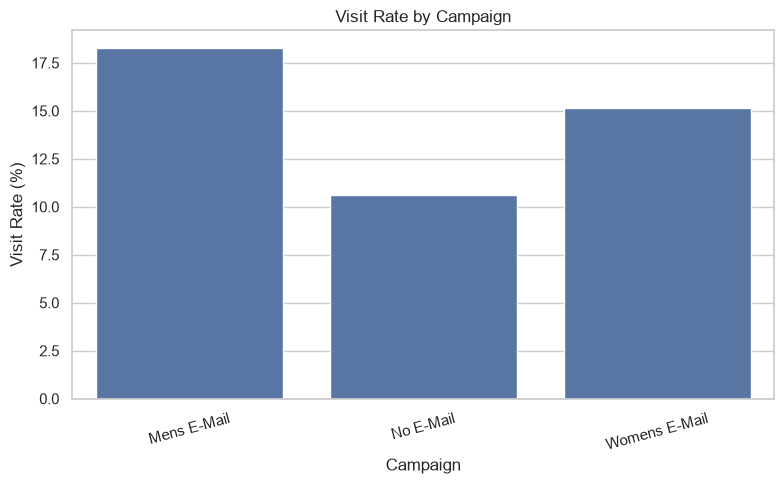

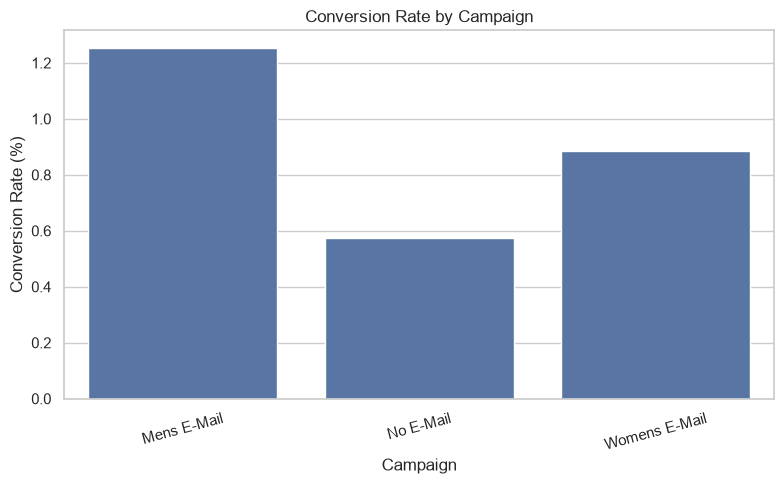

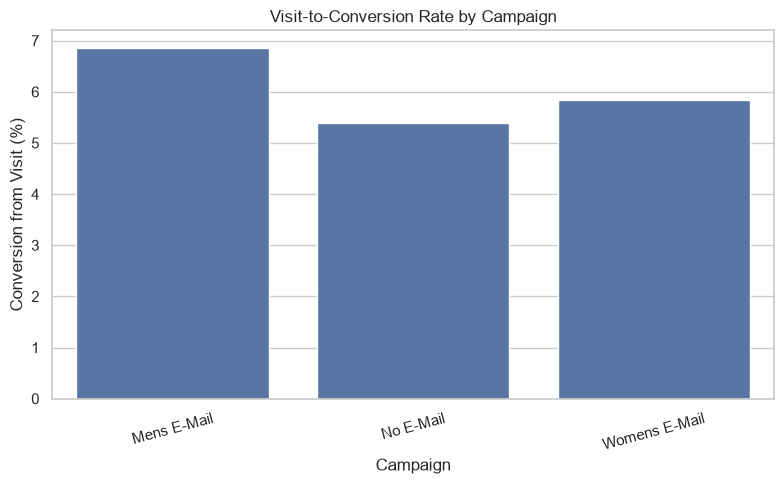

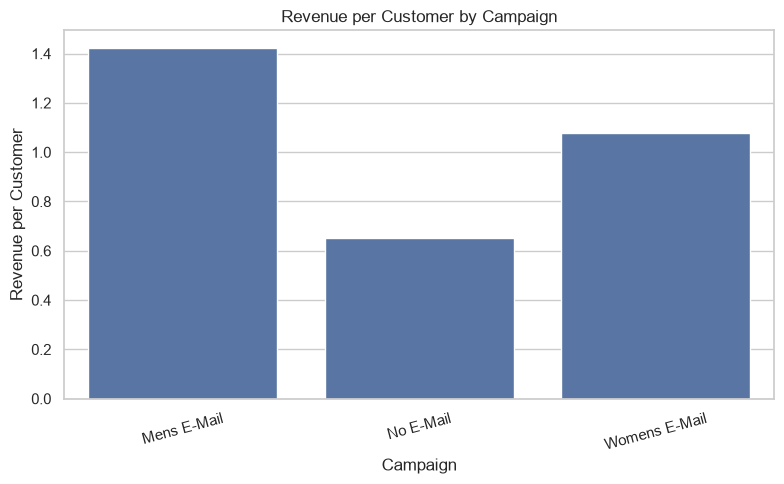

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 1. Visit Rate
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="visit_rate")
plt.title("Visit Rate by Campaign")
plt.ylabel("Visit Rate (%)")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/01_visit_rate.png", dpi=300)
plt.show()

# 2. Conversion Rate
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="conversion_rate")
plt.title("Conversion Rate by Campaign")
plt.ylabel("Conversion Rate (%)")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/02_conversion_rate.png", dpi=300)
plt.show()

# 3. Conversion from Visit
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="conversion_from_visit")
plt.title("Visit-to-Conversion Rate by Campaign")
plt.ylabel("Conversion from Visit (%)")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# 4. Revenue per Customer
plt.figure(figsize=(8, 5))
sns.barplot(data=summary.reset_index(), x="segment", y="revenue_per_customer")
plt.title("Revenue per Customer by Campaign")
plt.ylabel("Revenue per Customer")
plt.xlabel("Campaign")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../visualizations/04_revenue_per_customer.png", dpi=300)
plt.show()